In [1]:
#%%
""" Analysis of the results of the celebA experiment. """

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scienceplots

sns.set_theme(context='talk', style='ticks',
        font='sans-serif', font_scale=1, color_codes=True, rc={"lines.linewidth": 2})

# plt.style.use(['science', 'no-latex'])

## Set the following matplotlib parameters 
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

In [2]:
## Parse the files in the folders in the runs directory
csv_files = "results_all.csv"
## Add headers to the csv file
header = "method,taylor_order,nb_shots,outer_steps,walltime,mse_train,mse_val,ci_val,mse_test,ci_test,folder\n"
os.system(f"echo '{header}' > {csv_files}")

## loop throught the folders in runs (first level)
for folder in os.listdir("runs"):
    if folder != ".gitignore":
        print(f"Currently dealing with folder runs/{folder}")

        for file in os.listdir(f"runs/{folder}"):
            if file.endswith(".py"):
            #     os.system(f"cat runs/{folder}/{file} >> {csv_files}")

                ## Extract the method, taylor_order, and nb_shots from the .py file. e.g. CAVIA-TO0-K10.py
                method = file.split("-")[0]
                taylor_order = file.split("-")[1].split("TO")[1]
                nb_shots = file.split("-")[2].split("K")[1][:-3]
                break

        ## Parse the nohup.log file to extract the remaining information. And example output might be like:
        """ 
        === Beginning Meta-Training ... ===
            Number of examples in a batch: 512
            Total number of batches : 318
            Number of outer steps: 300
            Numbers of inner steps : 4
            Training on 318 batches 
            
            Epoch: 299      Batch: 300    Loss: 0.00077992     ContextsNorm: 0.00000000      Time/Step(s): 0.0042
            Epoch: 299      Batch: 317    Loss: 0.00082109     ContextsNorm: 0.00000000      Time/Step(s): 0.0039

            Total gradient descent training time: 0 hours 41 mins 38 secs

            Test loss value: 9.94e-02 ± 3.75e-02
            Train loss value for criterion 0: 1.41e-03
            
            Test loss value: 9.87e-02 ± 3.78e-02
            Train loss value for criterion 0: 1.36e-03

        """
        ## Check that nohup file exists. If so, fill the csv with NaNs
        if not os.path.exists(f"runs/{folder}/nohup.log"):
            os.system(f"echo '{method},{taylor_order},{nb_shots},NaN,NaN,NaN,NaN,NaN,NaN,NaN,{folder}' >> {csv_files}")
            continue

        with open(f"runs/{folder}/nohup.log") as f:
            lines = f.readlines()
            outer_steps = 0
            walltime = 0
            mse_train = 0
            mse_val = 0
            ci_val = 0
            mse_test = 0
            ci_test = 0

            val_done = False
            time_done = False

            for line in lines:
                if "Number of outer steps" in line:
                    outer_steps = line.split(":")[1].strip()
                if ("Total gradient descent training time" in line) and (time_done==False):
                    walltime = line.split(":")[1].strip()
                    time_done = True
                if ("ContextsNorm" in line):
                    # print("Current folder and file is:", folder, file, line.split("Loss:")[1])
                    try:
                        mse_train = line.split("Loss:")[1][:10].strip()
                    except IndexError:
                        mes_train = line.split("LossModel:")[1][:10].strip()
                    # mse_train = line.split("Loss:")[1][:10].strip()
                if ("Test loss value" in line) and (val_done==False):
                    mse_val = line.split(":")[1].split("±")[0].strip()
                    ci_val = line.split(":")[1].split("±")[1].strip()
                    val_done = True
                if ("Test loss value" in line) and (val_done==True):
                    mse_test = line.split(":")[1].split("±")[0].strip()
                    ci_test = line.split(":")[1].split("±")[1].strip()

            ## Append the results to the csv file
            os.system(f"echo '{method},{taylor_order},{nb_shots},{outer_steps},{walltime},{mse_train},{mse_val},{ci_val},{mse_test},{ci_test},{folder}' >> {csv_files}")

            # print("Values collected are:\n", method, taylor_order, nb_shots, outer_steps, walltime, mse_train, mse_val, ci_val, mse_test, ci_test)

Currently dealing with folder runs/240925-032648
Currently dealing with folder runs/240926-194910
Currently dealing with folder runs/240925-084558
Currently dealing with folder runs/240925-021058
Currently dealing with folder runs/240924-223628
Currently dealing with folder runs/240925-101039
Currently dealing with folder runs/240926-170811
Currently dealing with folder runs/240924-215429
Currently dealing with folder runs/240925-000154
Currently dealing with folder runs/240926-142651
Currently dealing with folder runs/240926-224149
Currently dealing with folder runs/240926-235834
Currently dealing with folder runs/240925-212550
Currently dealing with folder runs/240926-113729
Currently dealing with folder runs/240925-195507
Currently dealing with folder runs/240925-021117
Currently dealing with folder runs/240925-225513
Currently dealing with folder runs/240925-133801
Currently dealing with folder runs/240926-183238
Currently dealing with folder runs/240925-053518
Currently dealing wi

In [3]:
results = pd.read_csv(csv_files)

## Sort by method, then by taylor_order, then by nb_shots
results = results.sort_values(by=['method', 'taylor_order', 'nb_shots'])

# ## Remove the mse_train column
# results = results.drop(columns=['mse_train', "folder", "outer_steps", "walltime"])

# ## Rename mse_val as mse_train
# results = results.rename(columns={'mse_val': 'mse_train', 'ci_val': 'ci_train'})
# results = results.rename(columns={'mse_test': 'mse_adapt', 'ci_test': 'ci_adapt'})

print(len(results))
results

## Dumpt to a csv file
# results.to_csv("results_table.csv", index=False)

36


,method,taylor_order,nb_shots,outer_steps,walltime,mse_train,mse_val,ci_val,mse_test,ci_test,folder
7,CAVIA,0,10,300.0,0 hours 41 mins 38 secs,0.000821,0.0994,0.03750,0.0987,0.0378,240924-215429
8,CAVIA,0,100,300.0,0 hours 45 mins 10 secs,0.005125,0.1360,0.06700,0.1350,0.0672,240925-000154
3,CAVIA,0,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,240925-021058
0,CAVIA,1,10,300.0,0 hours 42 mins 18 secs,0.002088,0.1030,0.04620,0.1010,0.0456,240925-032648
19,CAVIA,1,100,300.0,3 hours 10 mins 18 secs,0.011772,0.1370,0.07380,0.1370,0.0737,240925-053518
32,CAVIA,1,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,240925-101016
27,CAVIA,2,10,300.0,0 hours 43 mins 37 secs,0.001937,0.1010,0.04780,0.0998,0.0472,240925-112655
17,CAVIA,2,100,300.0,4 hours 51 mins 23 secs,0.011865,0.1370,0.07370,0.1360,0.0740,240925-133801
14,CAVIA,2,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,240925-195507
29,CAVIA,3,10,60.0,0 hours 13 mins 9 secs,0.003370,0.1050,0.04840,0.1030,0.0486,240925-211219


,method,taylor_order,nb_shots,outer_steps,walltime,mse_train,mse_val,ci_val,mse_test,ci_test,folder
3,CAVIA,0,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,240925-021058
32,CAVIA,1,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,240925-101016
14,CAVIA,2,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,240925-195507
33,CAVIA,3,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,240926-002316
15,NCF_NOALM,0,1000,0.0,1 hours 15 mins 12 secs,0.038665,0.0323,0.0159,0.0321,0.0168,240925-021117
5,NCF_NOALM,1,1000,0.0,1 hours 15 mins 55 secs,0.037459,0.0310,0.0149,0.0322,0.0164,240925-101039
20,NCF_NOALM,2,1000,0.0,1 hours 16 mins 25 secs,0.040585,0.0328,0.0161,0.0328,0.0171,240925-195533
30,NCF_NOALM,3,1000,0.0,1 hours 18 mins 25 secs,0.038762,0.0313,0.0147,0.0328,0.0169,240926-002354
9,NCF_PAML,0,1000,0.0,1 hours 15 mins 11 secs,0.037786,0.0329,0.0152,0.0342,0.0173,240926-142651
18,NCF_PAML,1,1000,0.0,1 hours 16 mins 9 secs,0.039210,0.0337,0.0160,0.0353,0.0164,240926-183238


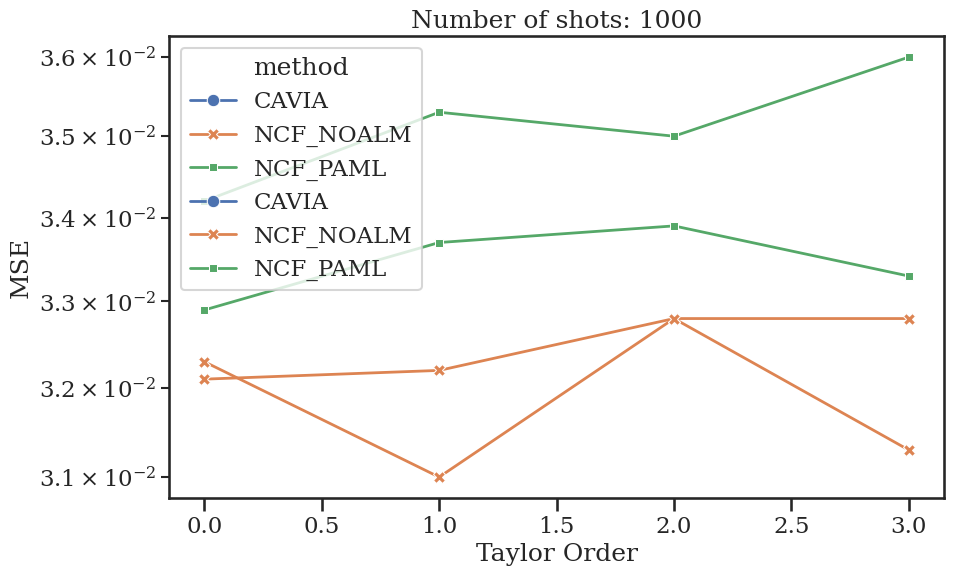

In [5]:
## PLot the results of a subset of the dataframe
plot_nb_shots = 1000

condition = (results['nb_shots'] == plot_nb_shots)
sub_results = results[condition]
display(sub_results)

## Plot all the mse_val and mse_test, along with the confidence intervals. Use shades of red for CAVIA, blue for NCF_NOAML, and green for NCF_PAML

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
sns.lineplot(data=sub_results, x='taylor_order', y='mse_val', hue='method', style='method', ax=ax, markers=True, dashes=False)
sns.lineplot(data=sub_results, x='taylor_order', y='mse_test', hue='method', style='method', ax=ax, markers=True, dashes=False)

ax.set_yscale('log')
plt.xlabel("Taylor Order")
plt.ylabel("MSE")
plt.title(f"Number of shots: {plot_nb_shots}")
plt.show()
